Post-processing eccentricity posterior using [gw_eccentricity](https://github.com/vijayvarma392/gw_eccentricity)<br>
In this example, we use a parameter estimation result file from [Bilby](https://git.ligo.org/lscsoft/bilby)

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np

# Path to PE result file

In [2]:
# result_file = "/Users/arif/Desktop/TEOB_chi0_9_ecc0_1_samples.hdf5" #"/Users/arif/Desktop/TEOB_chi0_9_ecc0_3_samples.hdf5"
# injection_file = "/Users/arif/Desktop/injection_params_TEOB_chi0_9_ecc0_1_samples.dat"#"/Users/arif/Desktop/injection.dat"
result_file = "/Users/arif/Desktop/TEOB_chi0_9_ecc0_3_samples.hdf5"
injection_file = "/Users/arif/Desktop/injection.dat"

# Postprocess the posterior file

For postprocessing Bilby result, we will use the derived class `PostProcessForBilby`

In [3]:
from gw_eccentricity.postprocess import PostProcessForBilby

/Users/arif/gw_eccentricity/gw_eccentricity/load_data.py:7: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


## Create a datadict generator

In addition to the posterior result file, we need to provide a `data_dict_generator` function which given an index, representing a row in the posterior DataFrame, returns a data_dict that will be used to measure eccentricity using `gw_eccentricity.measure_eccentricity`

The intrinsic parameters (reference frequency, masses, spins, eccentricity and mean anomaly) should match the parameters used to generate the waveforms when using bilby

In [4]:
import sys
sys.path.append("/Users/arif/teobresums_reviewed/Python/")

In [5]:
from teob_backward_evolution import teob_data_dict_generator

Check that the data_dict generated using `dataDict_generator` makes sense

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

## Instantiate PostProcessForBilby class

Now we use the posterior result file and the `data_dict_generator` to instantiate an instance of  `PostProcessForBilby` class

In [7]:
# If  None, it works with the full posterior. We can work with only the relevant columns
parameter_columns = ["mass_1", "mass_2", "spin_1z", "spin_2z", "luminosity_distance", "minimum_frequency", "eccentricity", "mean_per_ano"]

egwBilby = PostProcessForBilby(result_file, data_dict_generator=teob_data_dict_generator,
                              data_dict_generator_extra_kwargs={"ode_tmax": 1, "backwards": "yes"},
                              injection_file=injection_file,
                              parameter_columns=parameter_columns)

11:46 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data


## Looking at the original posteriors

In [8]:
egwBilby.posterior

,mass_1,mass_2,spin_1z,spin_2z,luminosity_distance,minimum_frequency,eccentricity,mean_per_ano
0,69.606326,48.389912,0.892924,0.840667,1863.475251,10.0,0.340209,2.603613
1,64.705539,52.509656,0.860734,0.884071,1459.715426,10.0,0.339408,3.756373
2,70.723160,46.216547,0.886695,0.756452,1867.117849,10.0,0.345114,2.279949
3,64.484123,52.938299,0.841869,0.868357,1974.297198,10.0,0.318437,0.244970
4,69.566824,45.800200,0.808252,0.812520,1853.087114,10.0,0.340370,0.608621
...,...,...,...,...,...,...,...,...
12723,59.868980,59.008436,0.893773,0.885188,1300.068425,10.0,0.308731,0.136035
12724,59.387763,59.054519,0.898561,0.881033,1228.920873,10.0,0.315228,0.294770
12725,59.715984,58.658780,0.883390,0.888504,1191.262543,10.0,0.312949,0.207168
12726,59.758918,59.013007,0.895735,0.890064,1309.544600,10.0,0.310986,0.184705


We can also load the injection in case we are doing an injection using model waveform.

In [9]:
injection = egwBilby.get_injection()

In [10]:
data_dict = egwBilby.get_injection_data_dict()

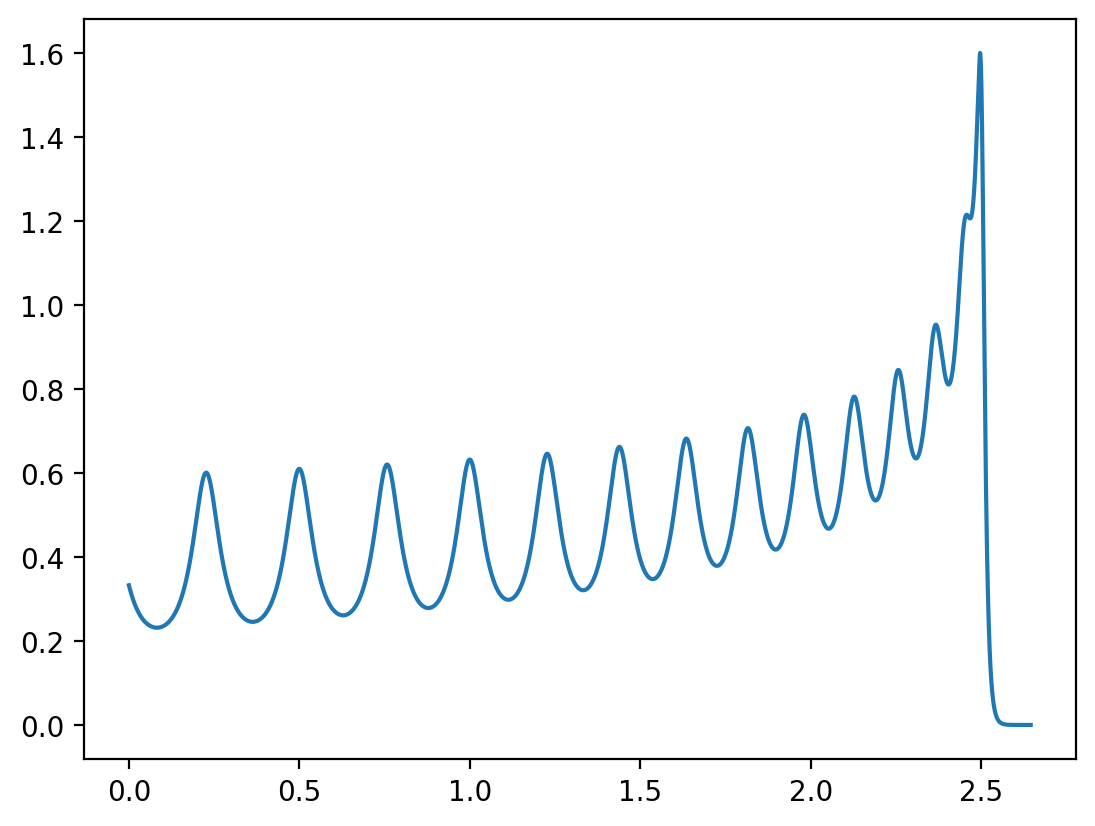

In [11]:
plt.plot(data_dict["t"], np.abs(data_dict["amplm"][(2, 2)]))

Finally plot the model posterior

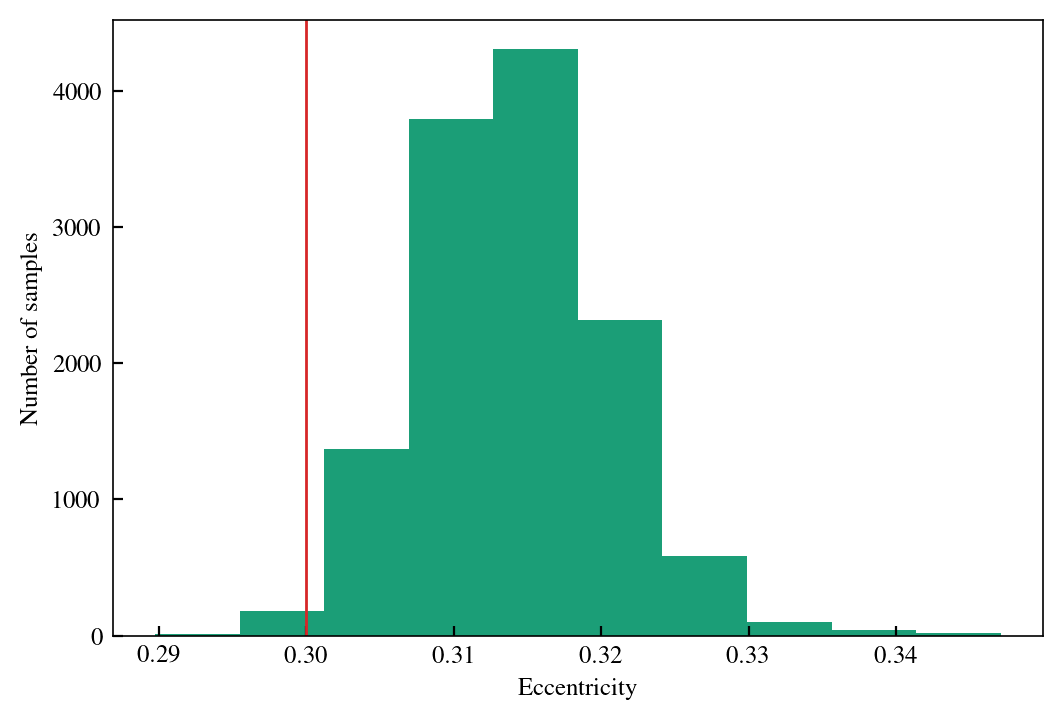

In [32]:
fig, ax = egwBilby.plot_eccentricity_posterior(**{"bins": 10})
ax.axvline(injection["eccentricity"], c="tab:red")

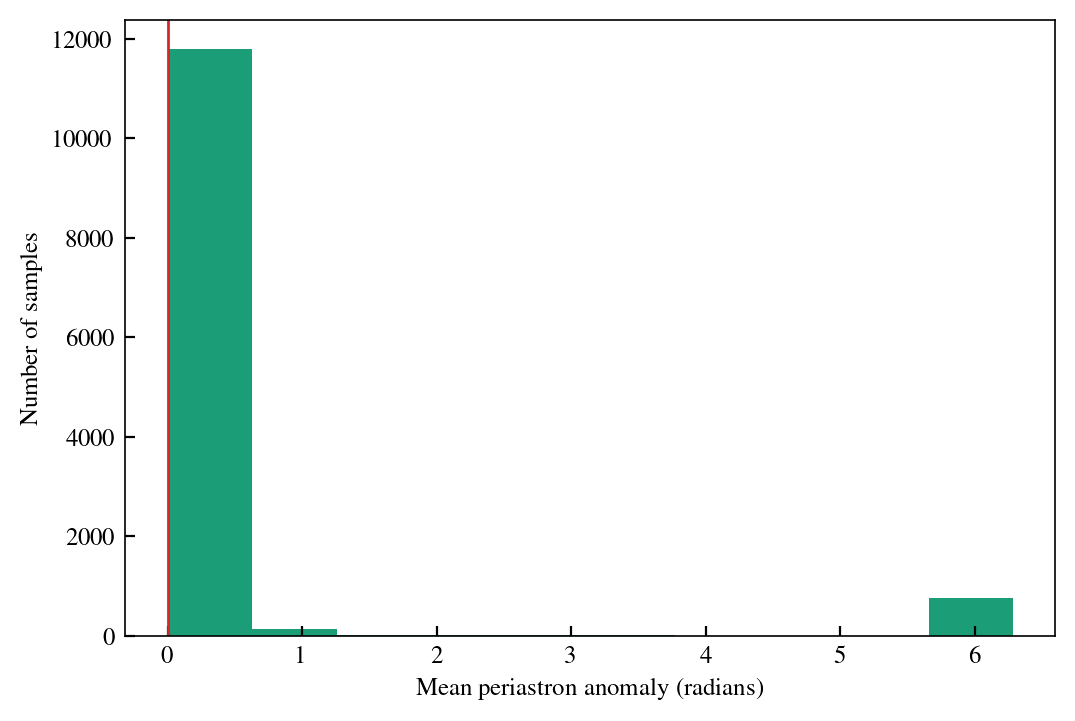

In [33]:
fig, ax = egwBilby.plot_mean_per_ano_posterior(**{"bins": 10})
ax.axvline(injection["mean_per_ano"], c="tab:red")

## Getting the allowed range of reference frequencies to use
Sometimes the chosen `fref`, the frequency where eccentricity and mean anomaly are to be measured could be outside the range where `egw` can be measured. Running the following code will give an idea of the `fref` bounds withing which majority of the samples can be post-processed.

This will also give an idea about how much backward evolving is required to get the orbit average frequency down to the desired `fref`.

In [13]:
import random

In [14]:
# we can use a subset of the samples to save time
samples = random.sample(range(0, len(egwBilby.posterior)), k=1000)

In [15]:
# some settings to use
method = "Amplitude"
gw_eccentricity_kwargs = {"extra_kwargs": {
    # "omega_gw_extrema_interpolation_method": "spline"
}}
n_jobs = 6

In [16]:
fref_bounds_result = egwBilby.get_fref_bounds(
    samples=samples,
    method=method,
    n_jobs=n_jobs,
    gw_eccentricity_kwargs=gw_eccentricity_kwargs)
print("Allowed range of reference frequencies are: ", fref_bounds_result.get_minmax_fref())

Getting fref bounds: 0it [00:00, ?it/s]/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: divide by zero encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: overflow encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: invalid value encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: divide by zero encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: overflow encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: invalid value encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Us

Allowed range of reference frequencies are:  (np.float64(8.62541826187073), np.float64(29.665828399702043))


The range of allowed reference frequencies comes from the samples where eccentricity measurement is successfull. We can get a summary of how many samples were successfully processed.

In [17]:
fref_bounds_result.get_summary()["success_percentage"]

100.0

We can also view the full result as a DataFrame

In [18]:
fref_bounds_result.to_dataframe()

,sample_index,status,fref_min,fref_max,error_message
0,7915,success,8.437405,31.180342,None
1,3505,success,8.509772,30.573267,None
2,3979,success,8.418719,31.358967,None
3,3396,success,8.506443,30.613973,None
4,2427,success,8.478854,30.904778,None
...,...,...,...,...,...
995,7749,success,8.459952,30.960169,None
996,5808,success,8.565001,30.238212,None
997,12253,success,8.478026,30.914471,None
998,788,success,8.487909,30.827255,None


## Postprocessing

We can postprocess a subset of the smaples or all the samples using the following method

In [19]:
import time

In [20]:
fref = 10
t_start = time.perf_counter()
samples = random.sample(range(0, len(egwBilby.posterior)), k=1000)
egwBilby.postprocess(fref=fref, samples=samples,
                      method=method,
                      gw_eccentricity_kwargs=gw_eccentricity_kwargs,
                      n_jobs=n_jobs)
t_stop = time.perf_counter()

Postprocessing samples: 270it [00:09, 26.38it/s]/Users/arif/gw_eccentricity/gw_eccentricity/eccDefinition.py:1757: UserWarning: Nonmonotonic time derivative detected in the rational_fit interpolant through pericenters. 
  debug_message(
Postprocessing samples: 558it [00:20, 25.47it/s]/Users/arif/gw_eccentricity/gw_eccentricity/eccDefinition.py:2767: UserWarning: egw(t) is nonmonotonic in the range [np.float64(2.35986328125), np.float64(2.3603515625)]
For more verbose output use `debug_level=1`.
  debug_message(message, self.debug_level,
Postprocessing samples: 564it [00:20, 25.38it/s]/Users/arif/gw_eccentricity/gw_eccentricity/eccDefinition.py:1757: UserWarning: Nonmonotonic time derivative detected in the rational_fit interpolant through pericenters. 
  debug_message(
Postprocessing samples: 636it [00:23, 25.51it/s]/Users/arif/gw_eccentricity/gw_eccentricity/eccDefinition.py:2767: UserWarning: egw(t) is nonmonotonic in the range [np.float64(2.35498046875), np.float64(2.356689453125)]


In [21]:
print(f"Took {t_stop - t_start} seconds for {len(samples)} samples on {n_jobs} cores.")

Took 38.98659979199874 seconds for 1000 samples on 6 cores.


### View the postprocessing results

In [22]:
egwBilby.postprocess_result.results[:5]

[PostProcessResult(sample_index=7270, status='success', egw=np.float64(0.3208831800810318), lgw=np.float64(2.5547339550597865), error_message=None),
 PostProcessResult(sample_index=799, status='success', egw=np.float64(0.3243438583675602), lgw=np.float64(2.2822553895215965), error_message=None),
 PostProcessResult(sample_index=4639, status='success', egw=np.float64(0.33982305290387527), lgw=np.float64(3.065017656439281), error_message=None),
 PostProcessResult(sample_index=472, status='success', egw=np.float64(0.3428560463857143), lgw=np.float64(3.199376228042878), error_message=None),
 PostProcessResult(sample_index=3091, status='success', egw=np.float64(0.3305045798289701), lgw=np.float64(2.8255217161142436), error_message=None)]

View as a DataFrame

In [23]:
egwBilby.postprocess_result.to_dataframe()

,sample_index,status,egw,lgw,error_message
0,7270,success,0.320883,2.554734,None
1,799,success,0.324344,2.282255,None
2,4639,success,0.339823,3.065018,None
3,472,success,0.342856,3.199376,None
4,3091,success,0.330505,2.825522,None
...,...,...,...,...,...
995,5048,success,0.321493,2.420520,None
996,9276,success,0.317992,2.379082,None
997,7870,success,0.326700,2.602691,None
998,8656,success,0.327009,2.850694,None


Get a summary

In [24]:
egwBilby.postprocess_result.get_summary()["success_percentage"]

100.0

Measure eccentricity of the injection

In [25]:
egw_inj, mean_ano_inj = egwBilby.get_injection_eccentricity(
    fref=fref,
    method=method,
    gw_eccentricity_kwargs=gw_eccentricity_kwargs,
)

/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: divide by zero encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: overflow encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: invalid value encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: divide by zero encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: overflow encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: invalid value encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:409: RuntimeWarning: divide by zero encountered in matmul
  q =

Plot the `egw` posterior

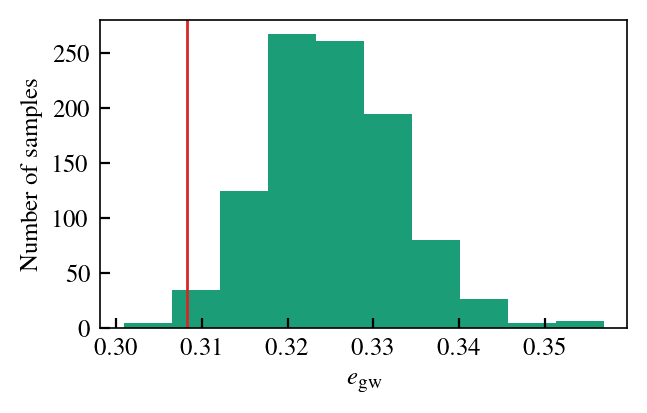

In [26]:
fig, ax = egwBilby.plot_egw_posterior(usetex=True, style="APS")
ax.axvline(egw_inj, c="tab:red")

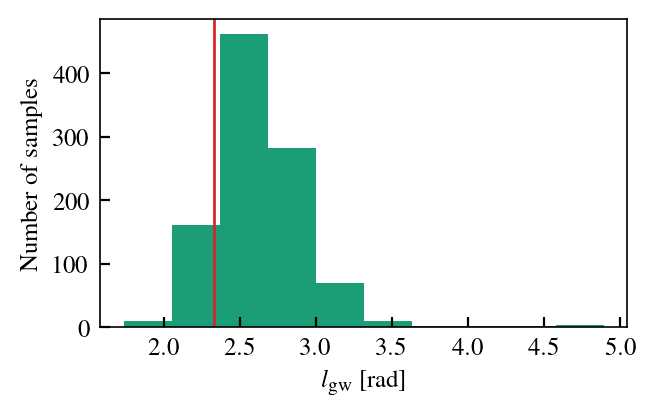

In [27]:
fig, ax = egwBilby.plot_lgw_posterior(usetex=True, style="APS")
ax.axvline(mean_ano_inj, c="tab:red")